In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
netflix=pd.read_csv("C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\data\\netflix_cleaned.csv")

In [3]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


In [4]:
netflix['date_added']=pd.to_datetime(netflix['date_added'].str.strip())

In [5]:
netflix.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
added_year               int64
dtype: object

In [6]:
netflix['country'].head(20)

0                                         United States
1                                          South Africa
2                                                   NaN
3                                                   NaN
4                                                 India
5                                                   NaN
6                                                   NaN
7     United States, Ghana, Burkina Faso, United Kin...
8                                        United Kingdom
9                                         United States
10                                                  NaN
11                                                  NaN
12                              Germany, Czech Republic
13                                                  NaN
14                                                  NaN
15                                        United States
16                                                  NaN
17                                              

In [7]:
netflix['country'].info()

<class 'pandas.Series'>
RangeIndex: 8797 entries, 0 to 8796
Series name: country
Non-Null Count  Dtype
--------------  -----
7967 non-null   str  
dtypes: str(1)
memory usage: 68.9 KB


In [8]:
netflix=netflix[~(netflix['country'].isna())]
netflix.shape

(7967, 13)

In [9]:
netflix[netflix['country'].str.contains(',')]['country'].shape

(1320,)

In [10]:
netflix[~(netflix['country'].str.contains(','))]['country'].shape

(6647,)

In [11]:
netflix[netflix['country'].str.contains(',')]['country'].value_counts()

country
United Kingdom, United States                    75
United States, Canada                            73
United States, United Kingdom                    47
Canada, United States                            45
France, Belgium                                  27
                                                 ..
Russia, Spain                                     1
Croatia, Slovenia, Serbia, Montenegro             1
Japan, Canada                                     1
United States, France, South Korea, Indonesia     1
United Arab Emirates, Jordan                      1
Name: count, Length: 675, dtype: int64

In [12]:
unique_country=[]
for countries in netflix['country'].tolist():
    if ',' in countries:
        for country in countries.split(','):
            country=country.strip()
            if country not in unique_country:
                unique_country.append(country)
    else:
        country=countries.strip()
        if country not in unique_country:
            unique_country.append(country)
unique_country

['United States',
 'South Africa',
 'India',
 'Ghana',
 'Burkina Faso',
 'United Kingdom',
 'Germany',
 'Ethiopia',
 'Czech Republic',
 'Mexico',
 'Turkey',
 'Australia',
 'France',
 'Finland',
 'China',
 'Canada',
 'Japan',
 'Nigeria',
 'Spain',
 'Belgium',
 'South Korea',
 'Singapore',
 'Italy',
 'Romania',
 'Argentina',
 'Venezuela',
 'Hong Kong',
 'Russia',
 '',
 'Ireland',
 'Nepal',
 'New Zealand',
 'Brazil',
 'Greece',
 'Jordan',
 'Colombia',
 'Switzerland',
 'Israel',
 'Taiwan',
 'Bulgaria',
 'Algeria',
 'Poland',
 'Saudi Arabia',
 'Thailand',
 'Indonesia',
 'Egypt',
 'Denmark',
 'Kuwait',
 'Netherlands',
 'Malaysia',
 'Vietnam',
 'Hungary',
 'Sweden',
 'Lebanon',
 'Syria',
 'Philippines',
 'Iceland',
 'United Arab Emirates',
 'Norway',
 'Qatar',
 'Mauritius',
 'Austria',
 'Cameroon',
 'Palestine',
 'Uruguay',
 'Kenya',
 'Chile',
 'Luxembourg',
 'Cambodia',
 'Bangladesh',
 'Portugal',
 'Cayman Islands',
 'Senegal',
 'Serbia',
 'Malta',
 'Namibia',
 'Angola',
 'Peru',
 'Mozambiqu

In [13]:
netflix['country']=netflix['country'].str.split(',')
netflix=netflix.explode('country',ignore_index=True)

In [14]:
netflix['country']=netflix['country'].str.strip()
netflix=netflix[netflix['country'] !='']
netflix['country'].value_counts().to_dict()

{'United States': 3684,
 'India': 1046,
 'United Kingdom': 805,
 'Canada': 445,
 'France': 393,
 'Japan': 317,
 'Spain': 232,
 'South Korea': 231,
 'Germany': 226,
 'Mexico': 169,
 'China': 162,
 'Australia': 159,
 'Egypt': 117,
 'Turkey': 113,
 'Hong Kong': 105,
 'Nigeria': 103,
 'Italy': 100,
 'Brazil': 97,
 'Argentina': 91,
 'Belgium': 90,
 'Indonesia': 90,
 'Taiwan': 89,
 'Philippines': 83,
 'Thailand': 70,
 'South Africa': 62,
 'Colombia': 52,
 'Netherlands': 50,
 'Denmark': 48,
 'Ireland': 46,
 'Sweden': 42,
 'Singapore': 41,
 'Poland': 41,
 'United Arab Emirates': 37,
 'New Zealand': 33,
 'Lebanon': 31,
 'Israel': 30,
 'Norway': 30,
 'Chile': 29,
 'Russia': 27,
 'Malaysia': 26,
 'Pakistan': 24,
 'Czech Republic': 22,
 'Switzerland': 19,
 'Romania': 14,
 'Uruguay': 14,
 'Saudi Arabia': 13,
 'Austria': 12,
 'Luxembourg': 12,
 'Finland': 11,
 'Greece': 11,
 'Hungary': 11,
 'Iceland': 11,
 'Bulgaria': 10,
 'Qatar': 10,
 'Peru': 10,
 'Jordan': 9,
 'Kuwait': 8,
 'Vietnam': 7,
 'Serbia

In [15]:
netflix.shape

(10003, 13)

In [16]:
netflix['country'].info()

<class 'pandas.Series'>
Index: 10003 entries, 0 to 10009
Series name: country
Non-Null Count  Dtype
--------------  -----
10003 non-null  str  
dtypes: str(1)
memory usage: 156.3 KB


In [17]:
netflix[netflix['country'].str.contains(',')]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year


In [18]:
n_country_by_year=pd.get_dummies(netflix,columns=['country'],dtype=int).groupby('added_year').sum(numeric_only=True).drop(columns='release_year')
n_country_by_year

,country_Afghanistan,country_Albania,country_Algeria,country_Angola,country_Argentina,country_Armenia,country_Australia,country_Austria,country_Azerbaijan,country_Bahamas,...,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States,country_Uruguay,country_Vatican City,country_Venezuela,country_Vietnam,country_West Germany,country_Zimbabwe
added_year,,,,,,,,,,,,,,,,,,,,,
2008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
2009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2010,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2011,0,0,0,0,0,0,0,0,0,0,...,0,0,1,12,0,0,0,0,0,0
2012,0,0,0,0,0,0,0,0,0,0,...,0,0,0,3,0,0,0,0,0,0
2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,10,0,0,0,0,0,0
2014,0,0,0,0,0,0,0,0,0,0,...,0,0,3,22,0,0,0,0,0,0
2015,0,0,0,0,0,0,5,0,0,0,...,1,0,8,57,0,0,0,0,0,0
2016,0,0,0,0,3,0,8,1,1,0,...,0,1,54,203,0,0,0,0,0,1


(array([   0.,  500., 1000., 1500., 2000., 2500.]),
 [Text(0.0, 0, '0'),
  Text(500.0, 0, '500'),
  Text(1000.0, 0, '1000'),
  Text(1500.0, 0, '1500'),
  Text(2000.0, 0, '2000'),
  Text(2500.0, 0, '2500')])

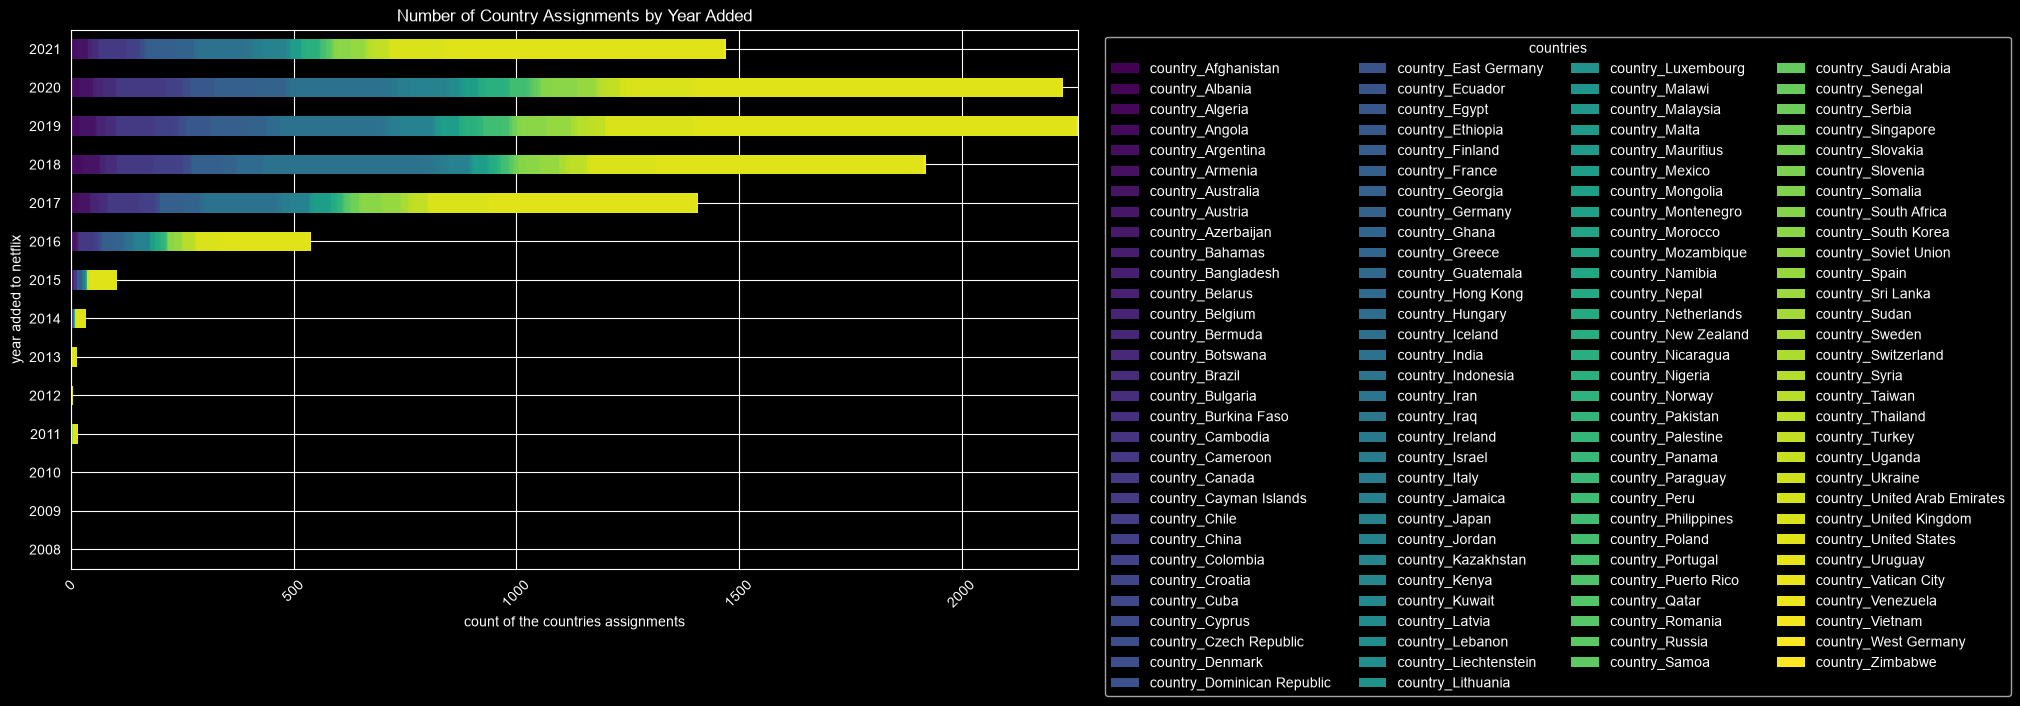

In [19]:
n_country_by_year.plot(kind='barh',stacked=True,figsize=(13,7),edgecolor='none',colormap='viridis')
plt.title('Number of Country Assignments by Year Added')
plt.ylabel('year added to netflix')
plt.xlabel('count of the countries assignments')
plt.legend(title='countries',loc='upper left',bbox_to_anchor=(1.02,1),ncol=4)
plt.xticks(rotation=45)

In [20]:
n_country_proportion=n_country_by_year.div(n_country_by_year.sum(axis=1),axis=0)*100
n_country_proportion

,country_Afghanistan,country_Albania,country_Algeria,country_Angola,country_Argentina,country_Armenia,country_Australia,country_Austria,country_Azerbaijan,country_Bahamas,...,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States,country_Uruguay,country_Vatican City,country_Venezuela,country_Vietnam,country_West Germany,country_Zimbabwe
added_year,,,,,,,,,,,,,,,,,,,,,
2008,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2009,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,5.882353,70.588235,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2013,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,7.692308,76.923077,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,8.823529,64.705882,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2015,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,4.854369,0.000000,0.000000,0.000000,...,0.970874,0.000000,7.766990,55.339806,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016,0.000000,0.00000,0.000000,0.000000,0.556586,0.000000,1.484230,0.185529,0.185529,0.000000,...,0.000000,0.185529,10.018553,37.662338,0.000000,0.000000,0.000000,0.000000,0.000000,0.185529


(array([  0.,  20.,  40.,  60.,  80., 100.]),
 [Text(0.0, 0, '0'),
  Text(20.0, 0, '20'),
  Text(40.0, 0, '40'),
  Text(60.0, 0, '60'),
  Text(80.0, 0, '80'),
  Text(100.0, 0, '100')])

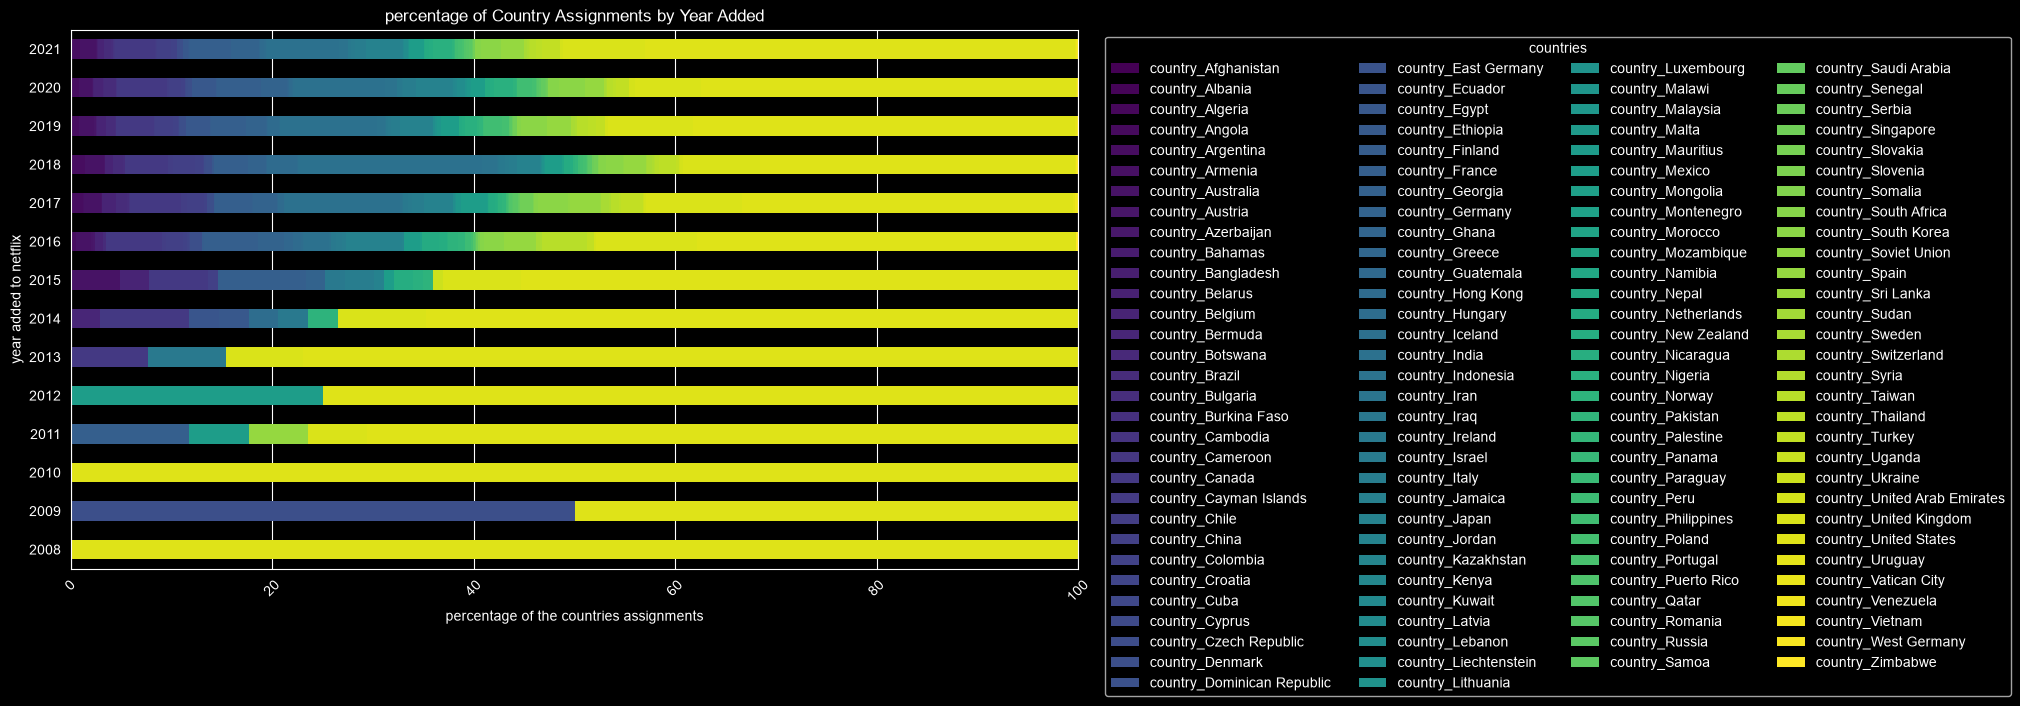

In [21]:
n_country_proportion.plot(kind='barh',stacked=True,figsize=(13,7),edgecolor='none',colormap='viridis')
plt.title('percentage of Country Assignments by Year Added')
plt.ylabel('year added to netflix')
plt.xlabel('percentage of the countries assignments')
plt.legend(title='countries',loc='upper left',bbox_to_anchor=(1.02,1),ncol=4)
plt.xticks(rotation=45)

(array([   0.,  200.,  400.,  600.,  800., 1000., 1200., 1400., 1600.,
        1800.]),
 [Text(0.0, 0, '0'),
  Text(200.0, 0, '200'),
  Text(400.0, 0, '400'),
  Text(600.0, 0, '600'),
  Text(800.0, 0, '800'),
  Text(1000.0, 0, '1000'),
  Text(1200.0, 0, '1200'),
  Text(1400.0, 0, '1400'),
  Text(1600.0, 0, '1600'),
  Text(1800.0, 0, '1800')])

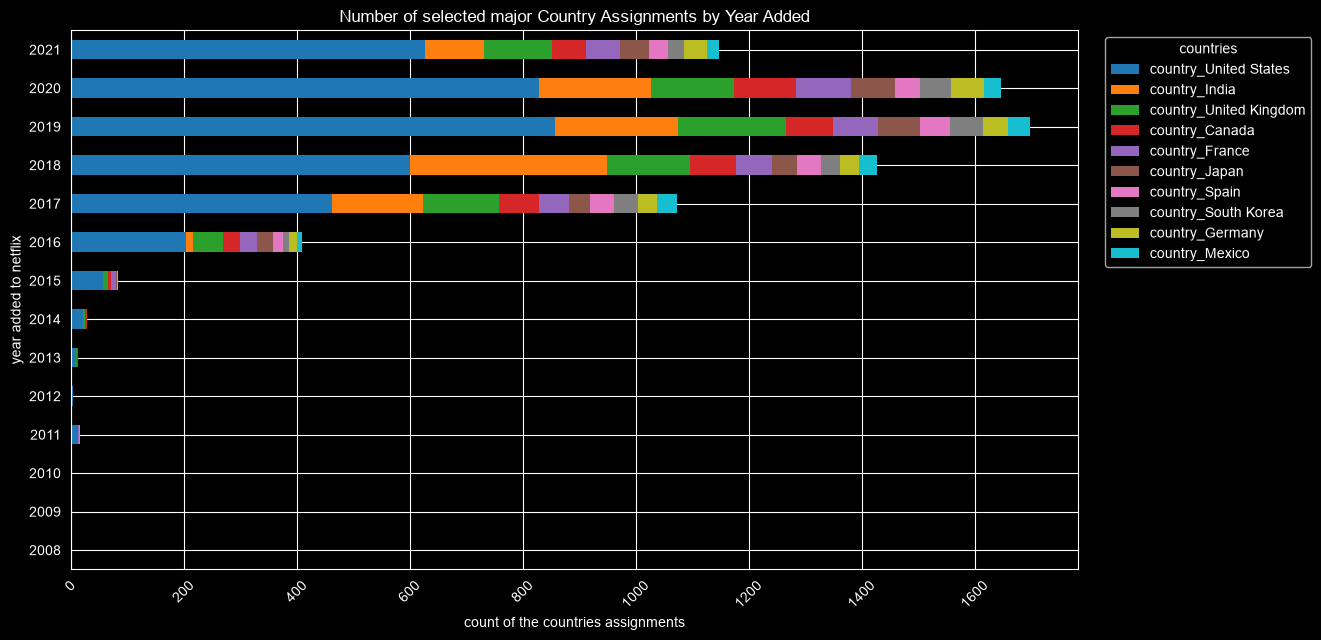

In [22]:
n_country_by_year.plot(kind='barh',y=[
    'country_United States',
    'country_India',
    'country_United Kingdom',
    'country_Canada',
    'country_France',
    'country_Japan',
    'country_Spain',
    'country_South Korea',
    'country_Germany',
    'country_Mexico'
],stacked=True,figsize=(13,7),edgecolor='none',colormap='tab10')
plt.title('Number of selected major Country Assignments by Year Added')
plt.ylabel('year added to netflix')
plt.xlabel('count of the countries assignments')
plt.legend(title='countries',loc='upper left',bbox_to_anchor=(1.02,1))
plt.xticks(rotation=45)

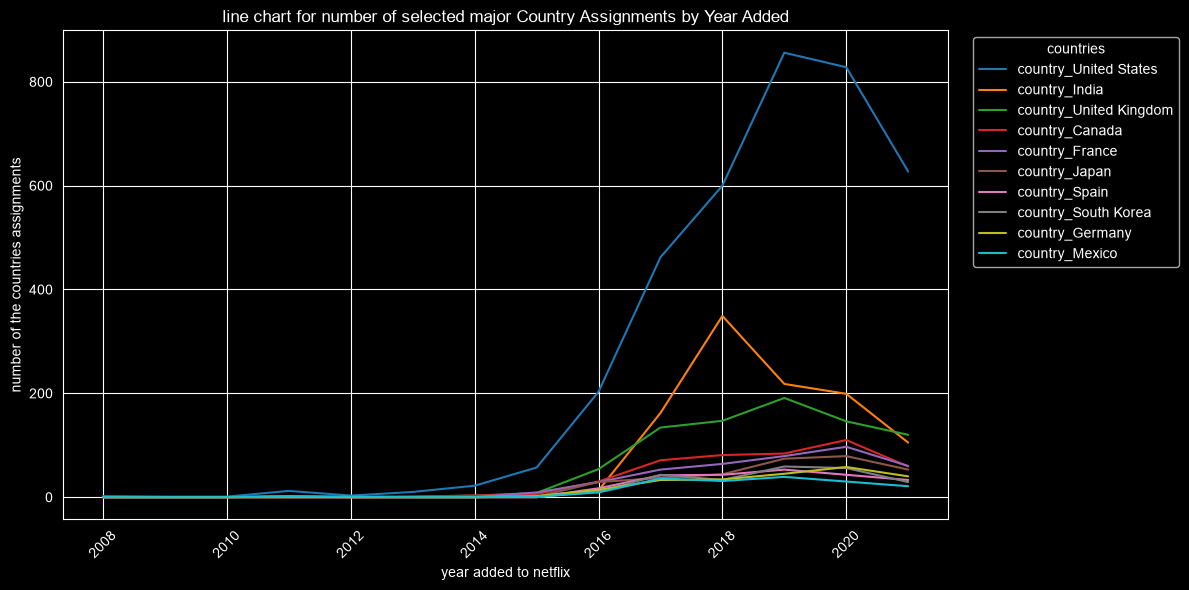

In [23]:
n_country_by_year.plot(y=[
    'country_United States',
    'country_India',
    'country_United Kingdom',
    'country_Canada',
    'country_France',
    'country_Japan',
    'country_Spain',
    'country_South Korea',
    'country_Germany',
    'country_Mexico'
],figsize=(12,6),colormap='tab10')
plt.title('line chart for number of selected major Country Assignments by Year Added')
plt.xlabel('year added to netflix')
plt.ylabel('number of the countries assignments')
plt.legend(title='countries',loc='upper left',bbox_to_anchor=(1.02,1))
plt.xticks(rotation=45)
plt.tight_layout()

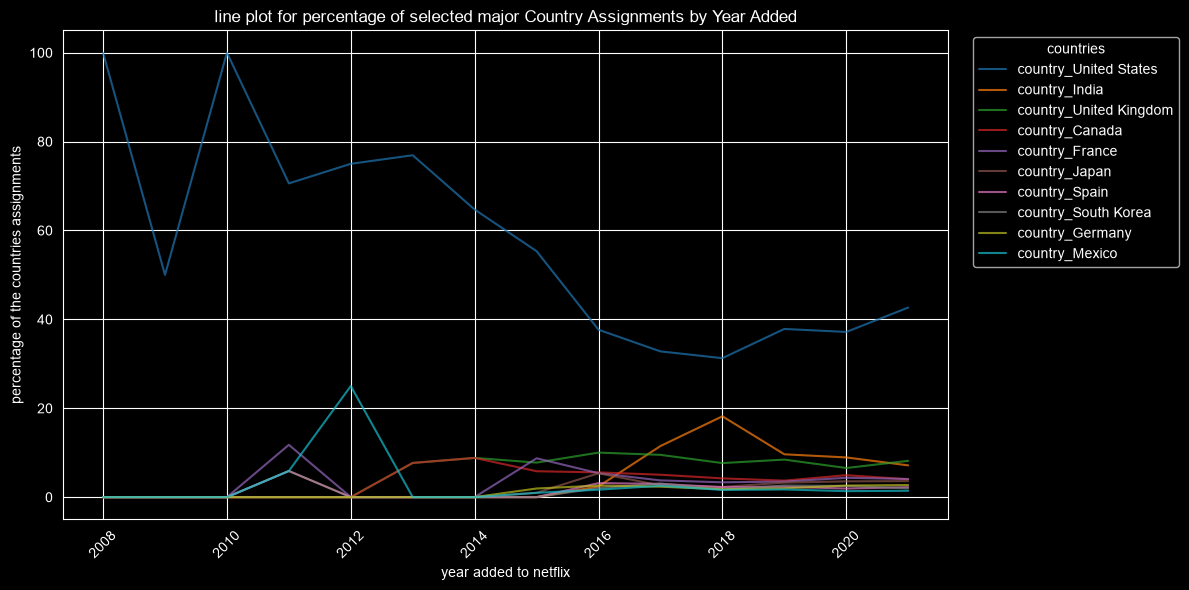

In [24]:
n_country_proportion.plot(y=[
    'country_United States',
    'country_India',
    'country_United Kingdom',
    'country_Canada',
    'country_France',
    'country_Japan',
    'country_Spain',
    'country_South Korea',
    'country_Germany',
    'country_Mexico'
],figsize=(12,6),colormap='tab10',alpha=0.7)
plt.title('line plot for percentage of selected major Country Assignments by Year Added')
plt.xlabel('year added to netflix')
plt.ylabel('percentage of the countries assignments')
plt.legend(title='countries',loc='upper left',bbox_to_anchor=(1.02,1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\images\\selected_major_country.png',dpi=300,bbox_inches='tight')

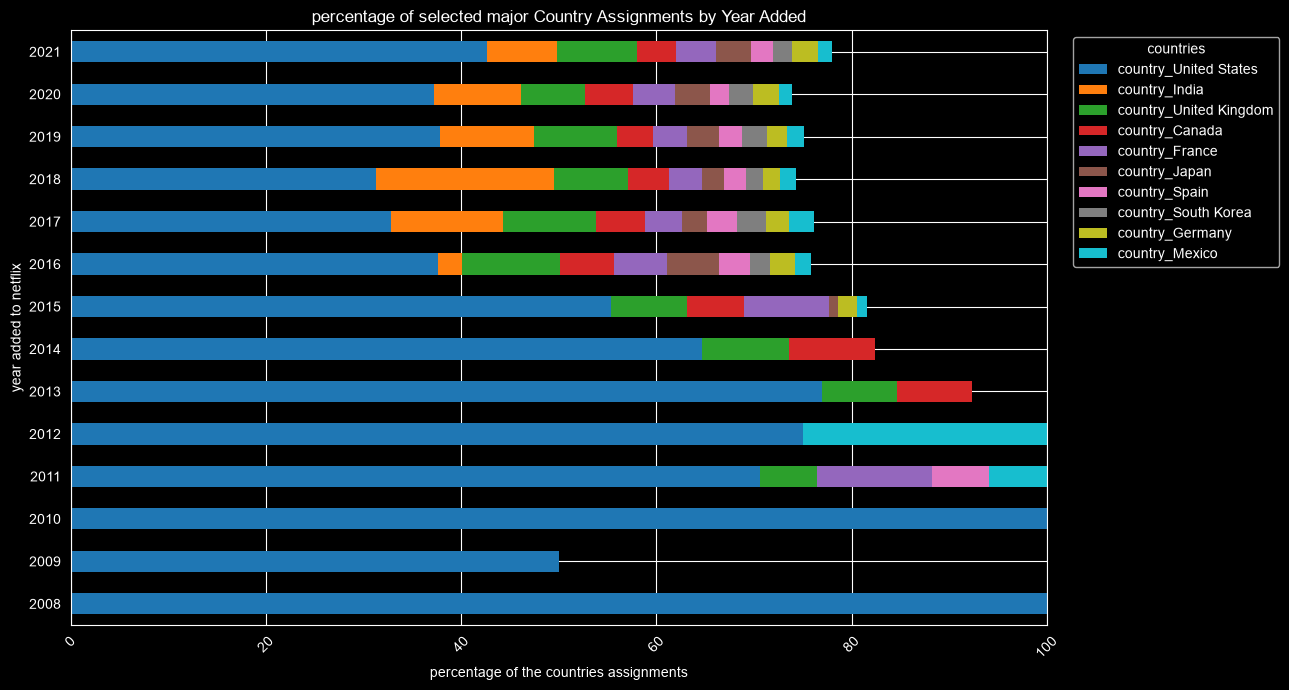

In [25]:
n_country_proportion.plot(kind='barh',y=[
    'country_United States',
    'country_India',
    'country_United Kingdom',
    'country_Canada',
    'country_France',
    'country_Japan',
    'country_Spain',
    'country_South Korea',
    'country_Germany',
    'country_Mexico'
],stacked=True,figsize=(13,7),edgecolor='none',colormap='tab10')
plt.title('percentage of selected major Country Assignments by Year Added')
plt.ylabel('year added to netflix')
plt.xlabel('percentage of the countries assignments')
plt.legend(title='countries',loc='upper left',bbox_to_anchor=(1.02,1))
plt.xticks(rotation=45)
plt.tight_layout()